In [7]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import r2_score


# zum import von py Dateien
from pathlib import Path
import sys

# Projekt-Root zum importieren von Helper
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from Helper import Helper 

In [8]:


r = ufloat(np.mean((1.98, 1.96, 1.98, 1.98, 1.99)),0.02)/2000 # Radius Draht in m
l = ufloat(10.33,0.005) # Einspannlänge cm

A =c.pi*(np.mean((1.98, 1.96, 1.98, 1.98, 1.99))/2000)**2

def Umrechnung(Bits):

    return Bits/120






Data = pd.read_csv("PS1-DI03.csv", sep=',', decimal='.')   # read csv für den Graphen


T = Data["Time since start of measurement"].to_numpy()    # Dehnung Data

F = Data["F"].to_numpy() 

# n = len(d)

# d_e = d[:int(round(n/3))]
# # s_e = s[:int(round(n/3))]
# print(d_e)
# print(s_e)


# # linfit
# popt, pcov = curve_fit(Helper.linfit, d_e, s_e, p0=[1, 1])

# a_opt, b_opt = popt
# x_model = np.linspace(0, 30, 100)
# y_model = Helper.linfit(x_model, a_opt, b_opt)
# perr = np.sqrt(np.diag(pcov))
# print(a_opt)
# r2 = Helper.r2_curve_fit(popt, d_e, s_e, Helper.linfit)


# plt.figure(figsize=(10, 6))
# # plt.scatter(E, N)
# plt.plot(d, s, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# # plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
# plt.xlabel("Dehnung")
# plt.ylabel("Spannung")
# plt.title("Spannungs-Dehnungs-Diagramm")
# plt.grid()
# plt.legend()
# plt.tight_layout()

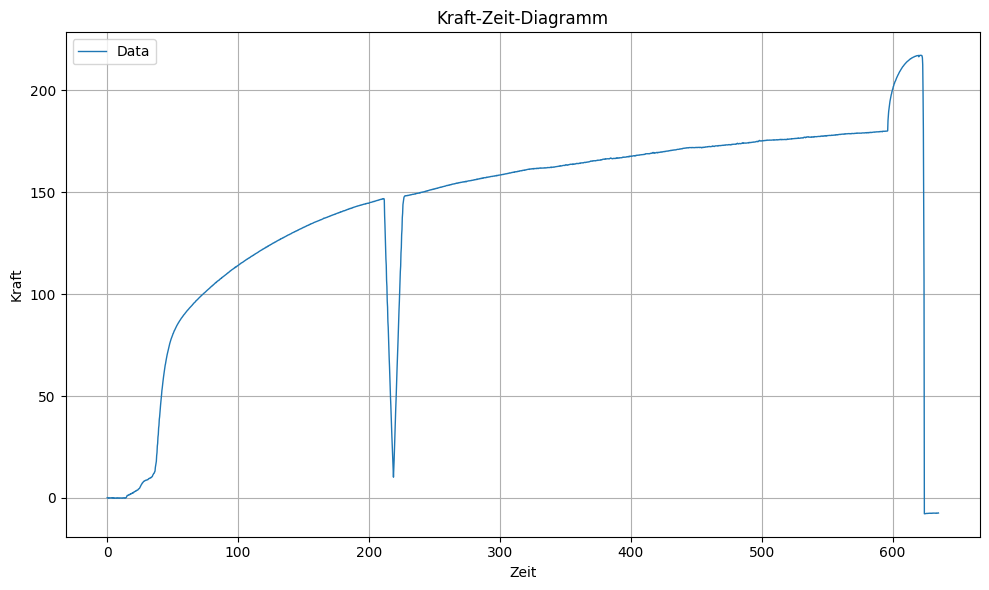

In [9]:
Data = pd.read_csv("PS1-DI03.csv", sep=',', decimal='.')   # read csv für den Graphen


T = Data["Time since start of measurement"].to_numpy()    # Dehnung Data

F = Data["F"].to_numpy()    # Spannung Data

F_n = Umrechnung(F)

plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(T, F_n, '-', linewidth=1, label="Data")
# plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("Zeit")
plt.ylabel("Kraft")
plt.title("Kraft-Zeit-Diagramm")
plt.grid()
plt.legend()
plt.tight_layout()

[72]
710149.8271228357
(7.10+/-0.09)e+05
[72]
0.83009379922244
0.830+/-0.016


/tmp/ipykernel_3613/4189482933.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s_lin = s_z[int(np.where(s_z ==np.min(s_z))[0]):105]
/tmp/ipykernel_3613/4189482933.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d_lin = d_z[int(np.where(s_z ==np.min(s_z))[0]):105]


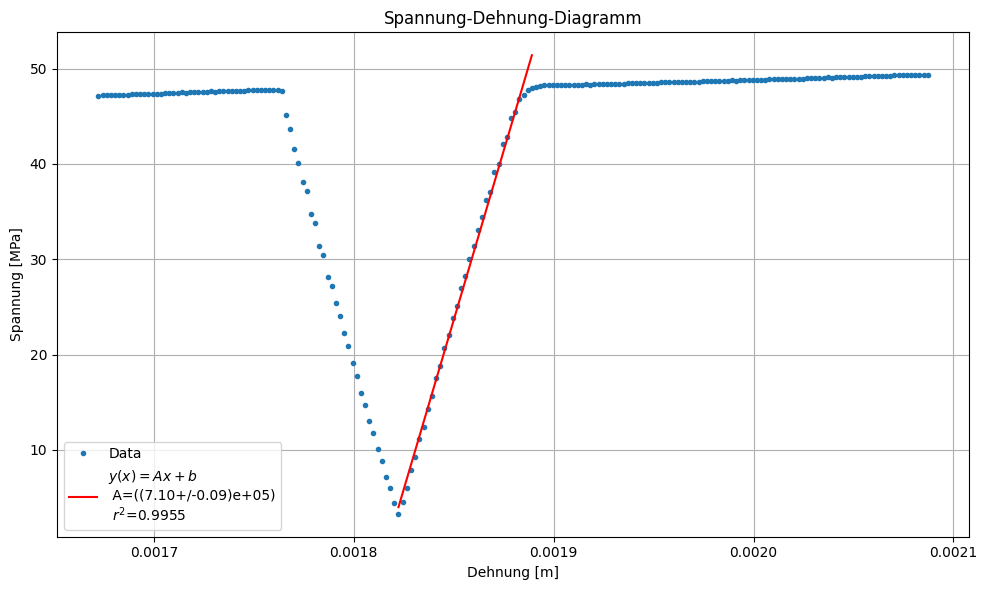

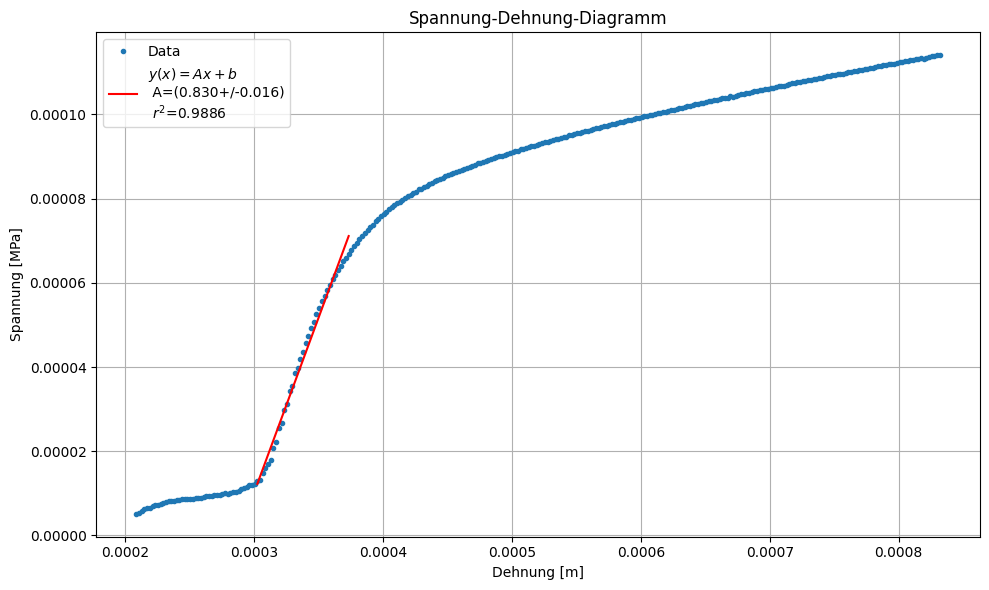

In [10]:
Data = pd.read_csv("PS1-DI03.csv", sep=',', decimal='.')   # read csv für den Graphen


T = Data["Time since start of measurement"].to_numpy()    # Dehnung Data

F = Data["F"].to_numpy()    # Spannung Data

F_n = Umrechnung(F)


T_z = T[802:1002]
F_z = F_n[802:1002]

s_z = F_z/(A*1000000)
d_z = T_z*0.5/60/1000

print(np.where(s_z ==np.min(s_z))[0])
s_lin = s_z[int(np.where(s_z ==np.min(s_z))[0]):105]
d_lin = d_z[int(np.where(s_z ==np.min(s_z))[0]):105]

# linfit
popt, pcov = curve_fit(Helper.linfit, d_lin, s_lin, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(d_lin),max(d_lin), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, d_lin, s_lin, Helper.linfit)
A = ufloat(a_opt,perr[0])
print(A)
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(d_z, s_z, '.', linewidth=1, label="Data")
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({A})\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("Dehnung [m]")
plt.ylabel("Spannung [MPa]")
plt.title("Spannung-Dehnung-Diagramm")
plt.grid()
plt.legend()
plt.tight_layout()



A=1

T_f = T[100:400]
F_f = F_n[100:400]

s_f = F_f/(A*1000000)
d_f = T_f*0.5/60/1000

print(np.where(s_z ==np.min(s_z))[0])
s_lin = s_f[45:80]
d_lin = d_f[45:80]
# linfit
popt, pcov = curve_fit(Helper.linfit, d_lin, s_lin, p0=[1, 1])

a_opt, b_opt = popt
x_model = np.linspace(min(d_lin),max(d_lin), 100)
y_model = Helper.linfit(x_model, a_opt, b_opt)
perr = np.sqrt(np.diag(pcov))
print(a_opt)
r2 = Helper.r2_curve_fit(popt, d_lin, s_lin, Helper.linfit)
A = ufloat(a_opt,perr[0])
print(A)
plt.figure(figsize=(10, 6))
# plt.scatter(E, N)
plt.plot(d_f, s_f, '.', linewidth=1, label="Data")
plt.plot(x_model, y_model, color='r', label=f"$y(x)=Ax+b$ \n A=({A})\n $r^2$={r2:.4f}")
# plt.plot(, N_Na, '-', linewidth=1, label="Na-22")
plt.xlabel("Dehnung [m]")
plt.ylabel("Spannung [MPa]")
plt.title("Spannung-Dehnung-Diagramm")
plt.grid()
plt.legend()
plt.tight_layout()

In [11]:
L = ufloat(np.mean((64.5,62.9)),0.3)/100 # Länge draht in m

l_2_1 = ufloat(11.5,0.3)/100   # Radius der Gewichte in m
l_2_2 = ufloat(17.5,0.3)/100
l_1_1 = ufloat(19/2,0.3)/100
l_1_2 = ufloat(37/2,0.3)/100
print(l_1_1)
print(l_1_2)
print(l_2_1)
print(l_2_2)
r = ufloat(np.mean((2.98,2.97,2.99,2.98,2.98)),0.02)/2000   # Dicke in m

m_1 = ufloat(np.mean((0.3725,0.373)),0.0005)    # Gewichte in kg
m_2 = ufloat(np.mean((0.249,0.2485)),0.0005)
print(m_1)
print(m_2)
T_2_1 = unp.uarray(np.mean(np.array([12.76, 13.09, 12.76, 12.84, 12.73, 12.95, 12.85, 12.78, 12.84, 12.75])),0.25)/10 #Dauer 1 Periode in s
T_2_2 = unp.uarray(np.mean(np.array([16.39, 16.65, 16.50, 16.31, 16.36, 16.17, 16.50, 16.24, 16.48, 16.54])),0.25)/10
T_1_1 = unp.uarray(np.mean(np.array([12.67, 12.76, 12.65, 12.84, 12.87, 12.80, 12.82, 12.92, 12.92, 12.75])),0.25)/10
T_1_2 = unp.uarray(np.mean(np.array([20.02, 19.89, 19.92, 19.75, 19.86, 20.10, 20.04, 20.09, 20.00, 19.90])),0.25)/10

def G(r,L,m,l_1,l_2,T_1,T_2):

    return 16*c.pi*((L*m)/(r**4))*(((l_1**2)-(l_2**2))/((T_1**2)-(T_2**2))) 

G_1 = G(r,L,m_1,l_1_1,l_1_2,T_1_1,T_1_2)
G_2 = G(r,L,m_2,l_2_1,l_2_2,T_2_1,T_2_2)
print(G_2)
print(G_1)
print(16*c.pi*((L*m_1)/(r**4)*(((l_1_1)**2-(l_1_2)**2)/(T_1_1**2-T_1_2**2))))

0.0950+/-0.0030
0.1850+/-0.0030
0.1150+/-0.0030
0.1750+/-0.0030
0.3728+/-0.0005
0.2487+/-0.0005
(2.69+/-0.34)e+10
(2.60+/-0.20)e+10
(2.60+/-0.20)e+10
